In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

In [22]:
df = pd.read_excel(
    "EastWestAirlines.xlsx",
    sheet_name=0,
    skiprows=1
)

df.head()

,"flying patterns, earning and use of frequent flyer rewards, and use of the airline credit",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN
4,(c) 2016 Galit Shmueli and Peter Bruce,NaN,NaN,NaN,NaN


In [23]:
print(df.columns)

Index(['flying patterns, earning and use of frequent flyer rewards, and use of the airline credit',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],
      dtype='object')


In [24]:
df.columns = df.columns.str.strip()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column                                                                                     Non-Null Count  Dtype 
---  ------                                                                                     --------------  ----- 
 0   flying patterns, earning and use of frequent flyer rewards, and use of the airline credit  17 non-null     object
 1   Unnamed: 1                                                                                 13 non-null     object
 2   Unnamed: 2                                                                                 6 non-null      object
 3   Unnamed: 3                                                                                 13 non-null     object
 4   Unnamed: 4                                                                                 18 non-null     object
dtypes: object(5)
memory usage: 1.1+ KB


In [26]:
df.describe()

,"flying patterns, earning and use of frequent flyer rewards, and use of the airline credit",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,17,13,6,13,18
unique,17,3,3,3,18
top,card. The task is to identify customer segmen...,NUMBER,1,Raw,Description
freq,1,9,3,9,1


In [27]:
df.isnull().sum()

,0
"flying patterns, earning and use of frequent flyer rewards, and use of the airline credit",8
Unnamed: 1,12
Unnamed: 2,19
Unnamed: 3,12
Unnamed: 4,7


# Exploratory Data Analysis (EDA)

EDA was performed to understand the structure of the dataset.

The following steps were performed:
- Checked dataset information
- Verified missing values
- Generated summary statistics
- Visualized distributions and correlations

EDA helps identify hidden patterns, outliers,
and relationships between variables.

In [28]:
df.fillna(
    df.mean(numeric_only=True),
    inplace=True
)

In [29]:
for col in df.columns:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [30]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

numeric_df = numeric_df.dropna(
    axis=1,
    how='all'
)

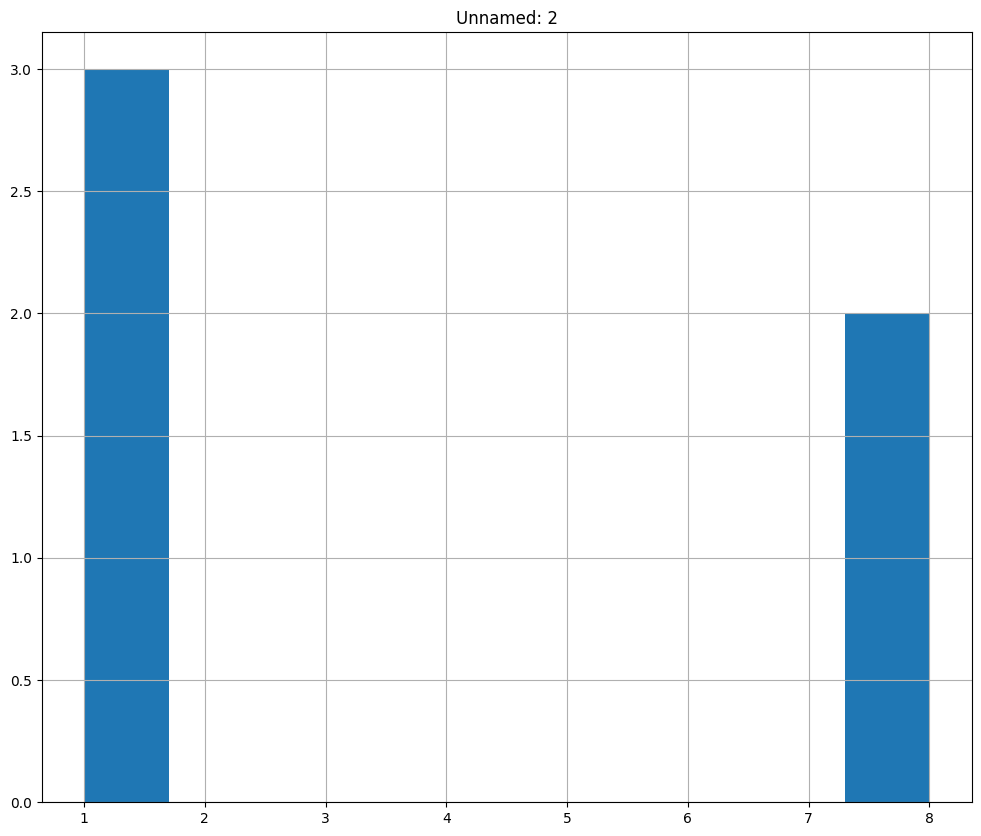

In [31]:
numeric_df.hist(figsize=(12,10))

plt.show()

# Histograms

Histograms were used to visualize the distribution
of numerical variables in the dataset.

They help identify skewness, spread,
and frequency patterns in the data.

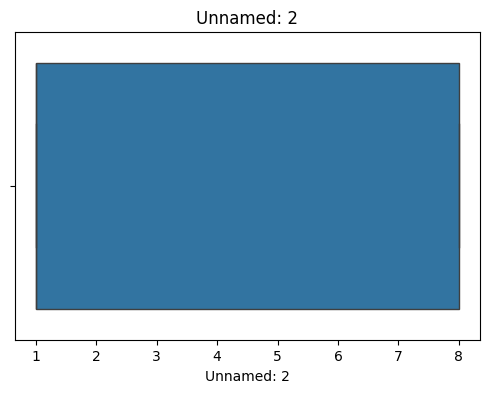

In [32]:
for col in numeric_df.columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=numeric_df[col].dropna()
    )

    plt.title(col)

    plt.show()

# Boxplots

Boxplots were used to identify outliers
and understand the spread of the data.

Outliers are observations that differ
significantly from other values.

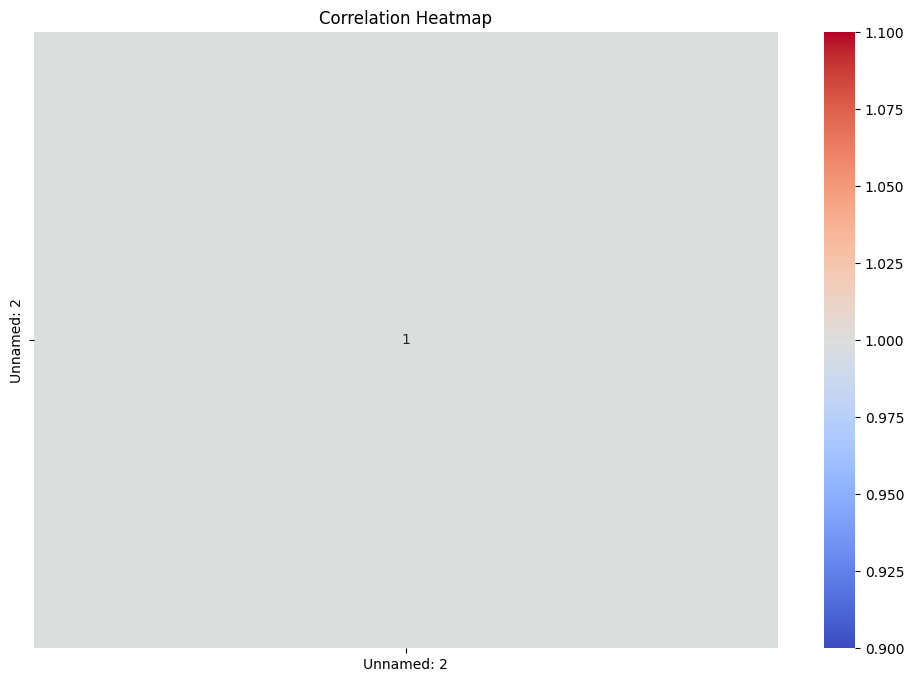

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Correlation Heatmap

The heatmap was used to analyze relationships
between variables.

Highly correlated variables indicate
strong relationships between features.

In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(numeric_df)

# Feature Scaling

Feature scaling was applied using StandardScaler.

Scaling ensures that all variables contribute equally
to distance calculations during clustering.

In [36]:
numeric_df_cleaned = numeric_df.fillna(numeric_df.mean())

x_scaled = StandardScaler().fit_transform(numeric_df_cleaned)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init='auto'
)

kmeans.fit(x_scaled)

kmeans_labels = kmeans.labels_

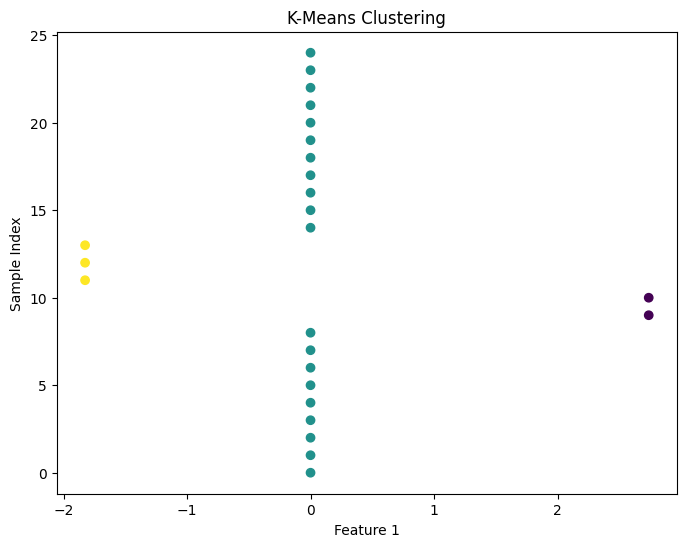

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_scaled[:,0],
    np.arange(len(x_scaled)),
    c=kmeans_labels
)

plt.title("K-Means Clustering")

plt.xlabel("Feature 1")

plt.ylabel("Sample Index")

plt.show()

In [40]:
kmeans_score = silhouette_score(
    x_scaled,
    kmeans_labels
)

print(
    "K-Means Silhouette Score:",
    kmeans_score
)

K-Means Silhouette Score: 1.0


# K-Means Interpretation

K-Means clustering grouped similar customers
based on feature similarity.

The Silhouette Score was used to evaluate
the clustering quality.

Higher scores indicate better cluster separation.

In [43]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(x_scaled)

In [48]:
dbscan_score = silhouette_score(
    x_scaled,
    dbscan_labels
)

print(
    "DBSCAN Silhouette Score:",
    dbscan_score
)

DBSCAN Silhouette Score: 0.76


# DBSCAN Interpretation

DBSCAN identifies dense regions and noise points.

Unlike K-Means, DBSCAN does not require
predefining the number of clusters.

It is effective for detecting irregular cluster shapes.

In [49]:
print(
    "K-Means Silhouette Score:",
    kmeans_score
)

print(
    "DBSCAN Silhouette Score:",
    dbscan_score
)

K-Means Silhouette Score: 1.0
DBSCAN Silhouette Score: 0.76


# Cluster Comparison

K-Means and DBSCAN clustering algorithms
were compared using Silhouette Score.

K-Means partitions the dataset into fixed clusters,
while DBSCAN identifies dense regions and noise points.

The comparison helps determine the most suitable
clustering algorithm for the dataset.

Conclusion

In this assignment, K-Means and DBSCAN clustering
algorithms were successfully implemented.

EDA and preprocessing techniques improved
data quality and clustering performance.

Feature scaling ensured fair distance calculations.

Clustering performance was evaluated using
Silhouette Score.